In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded")

Libraries loaded


## Load Raw Data

In [2]:
train_data = pd.read_csv('../data/raw/fraudTrain.csv')

if 'Unnamed: 0' in train_data.columns:
    train_data = train_data.drop('Unnamed: 0', axis=1)

print(f"Loaded: {train_data.shape[0]:,} rows * {train_data.shape[1]} columns")
print(f"Memory: {train_data.memory_usage(deep=True).sum() / 1024**2:.2f}")

Loaded: 1,296,675 rows * 22 columns
Memory: 1025.10


## Quick Look at the Data

In [3]:
train_data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.08,-81.18,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.01,-82.05,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.89,-118.21,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.16,-118.19,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.18,-112.26,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.15,-112.15,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.23,-112.11,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.03,-112.56,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.42,-79.46,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.67,-78.63,0


In [4]:
train_data.tail()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,UT,84735,37.72,-112.48,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.84,-111.69,0
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,MD,21790,39.27,-77.51,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.91,-78.25,0
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,NM,88325,32.94,-105.82,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.62,-105.13,0
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,Manderson,SD,57756,43.35,-102.54,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.79,-103.24,0
1296674,2020-06-21 12:13:37,4292902571056973207,"fraud_Langosh, Wintheiser and Hyatt",food_dining,4.30,Jeffrey,Smith,M,135 Joseph Mountains,Sula,MT,59871,45.84,-113.87,218,"Therapist, horticultural",1995-08-16,8f7c8e4ab7f25875d753b422917c98c9,1371816817,46.57,-114.19,0


In [5]:
train_data.sample(5, random_state=42)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1045211,2020-03-09 15:09:26,577588686219,fraud_Towne LLC,misc_pos,194.51,James,Strickland,M,25454 Leonard Lake,Spring Church,PA,15686,40.62,-79.45,972,Public relations account executive,1997-10-23,fff87d4340ef756a592eac652493cf6b,1362841766,40.42,-78.87,0
547406,2019-08-22 15:49:01,30376238035123,fraud_Friesen Ltd,health_fitness,52.32,Cynthia,Davis,F,7177 Steven Forges,Sixes,OR,97476,42.83,-124.44,217,Retail merchandiser,1928-10-01,d0ad335af432f35578eea01d639b3621,1345650541,42.76,-123.64,0
110142,2019-03-04 01:34:16,4658490815480264,fraud_Mohr Inc,shopping_pos,6.53,Tara,Richards,F,4879 Cristina Station,Keisterville,PA,15449,39.96,-79.79,184,Systems developer,1945-11-04,87f26e3ea33f4ff4c7a8bad2c7f48686,1330824856,40.48,-78.90,0
1285953,2020-06-16 20:04:38,3514897282719543,fraud_Gaylord-Powlowski,home,7.33,Steven,Faulkner,M,841 Cheryl Centers Suite 115,Farmington,NY,14425,42.96,-77.31,10717,Cytogeneticist,1952-10-13,9c34015321c0fa2ae6fd20f9359d1d3e,1371413078,43.77,-76.54,0
271705,2019-05-14 05:54:48,6011381817520024,"fraud_Christiansen, Goyette and Schamberger",gas_transport,64.29,Kristen,Allen,F,8619 Lisa Manors Apt. 871,Lagrange,WY,82221,41.64,-104.20,635,Product/process development scientist,1973-07-13,198437c05676f485e9be04449c664475,1336974888,41.04,-104.09,0


In [5]:
train_data.dtypes


trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

### Misssing Values Analysis


In [8]:
missing = train_data.isnull().sum()
missing = missing[missing > 0]
if  len(missing) == 0:
    print("[OK] No missing values - dataset is complete.")
else:
    print(missing)


[OK] No missing values - dataset is complete.


### Data Dictionary

> `card_type` is **not** a raw column. It is engineered in NB02 from the `cc_num`
> prefix using the Bank Identification Number (BIN) standard and is included here
> so the full analytical schema is documented in one place.

In [9]:
data_dict = pd.DataFrame({
    'Column': [
        'trans_date_trans_time','cc_num','card_type *','merchant','category',
        'amt','first','last','gender','street','city','state','zip',
        'lat','long','city_pop','job','dob','trans_num','unix_time',
        'merch_lat','merch_long','is_fraud'
    ],
    'Type': [
        'datetime','string','categorical (engineered)','categorical','categorical',
        'float','string','string','categorical','string','string','categorical','int',
        'float','float','int','string','date','string','int',
        'float','float','binary'
    ],
    'Description': [
        'Transaction date and time',
        'Credit card number (anonymised)',
        'Card network - derived from cc_num BIN prefix in NB02 (Visa / Mastercard / Amex / Discover / Other)',
        'Merchant name',
        'Merchant category (e.g. grocery_pos, shopping_net)',
        'Transaction amount in USD',
        'Cardholder first name','Cardholder last name',
        'Cardholder gender (M/F)',
        'Cardholder street address','Cardholder city',
        'Cardholder state (US 2-letter code)',
        'Cardholder ZIP code',
        'Cardholder home latitude','Cardholder home longitude',
        'Population of cardholder city',
        'Cardholder occupation',
        'Cardholder date of birth',
        'Unique transaction ID (MD5 hex string)',
        'Transaction Unix timestamp',
        'Merchant latitude','Merchant longitude',
        'Fraud label - 1 = Fraudulent, 0 = Legitimate'
    ]
})
print(data_dict.to_string(index=False))


               Column                     Type                                                                                         Description
trans_date_trans_time                 datetime                                                                           Transaction date and time
               cc_num                   string                                                                     Credit card number (anonymised)
          card_type * categorical (engineered) Card network - derived from cc_num BIN prefix in NB02 (Visa / Mastercard / Amex / Discover / Other)
             merchant              categorical                                                                                       Merchant name
             category              categorical                                                  Merchant category (e.g. grocery_pos, shopping_net)
                  amt                    float                                                                        

### Target Variable — Fraud Distribution

In [9]:
fraud_counts = train_data['is_fraud'].value_counts()
fraud_pct    = train_data['is_fraud'].value_counts(normalize=True) * 100

print("Fraud Label Distribution:")
print(f"  Legitimate (0): {fraud_counts[0]:,}  ({fraud_pct[0]:.2f}%)")
print(f"  Fraudulent (1): {fraud_counts[1]:,}  ({fraud_pct[1]:.4f}%)")
print(f"\nImbalance ratio — 1 fraud : {fraud_counts[0]/fraud_counts[1]:.0f} legitimate")


Fraud Label Distribution:
  Legitimate (0): 1,289,169  (99.42%)
  Fraudulent (1): 7,506  (0.5789%)

Imbalance ratio — 1 fraud : 172 legitimate


### Class Ditsribution and Imbalance Visualisation

Legitimate (0):  1,289,169  (99.4211%)
Fraudulent (1):      7,506  (0.5789%)
Imbalance ratio: 1 fraud : 172 legitimate


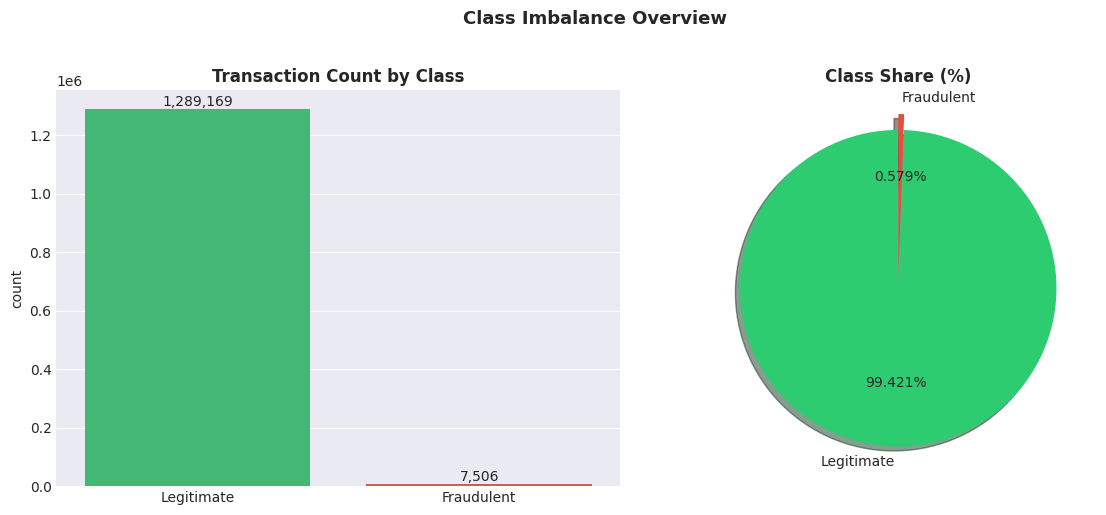

[OK] Saved: reports/nb01_class_imbalance.png


In [11]:
counts = train_data['is_fraud'].value_counts()
pcts   = train_data['is_fraud'].value_counts(normalize=True) * 100

print(f"Legitimate (0): {counts[0]:>10,}  ({pcts[0]:.4f}%)")
print(f"Fraudulent (1): {counts[1]:>10,}  ({pcts[1]:.4f}%)")
print(f"Imbalance ratio: 1 fraud : {counts[0]/counts[1]:.0f} legitimate")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=train_data, x='is_fraud', palette=['#2ecc71','#e74c3c'], ax=axes[0])
axes[0].set_title('Transaction Count by Class', fontweight='bold')
axes[0].set_xticklabels(['Legitimate', 'Fraudulent'])
axes[0].set_xlabel('')
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='{:,.0f}')

axes[1].pie([pcts[0], pcts[1]], labels=['Legitimate','Fraudulent'],
            autopct='%1.3f%%', colors=['#2ecc71','#e74c3c'],
            startangle=90, explode=(0,0.1), shadow=True)
axes[1].set_title('Class Share (%)', fontweight='bold')

plt.suptitle('Class Imbalance Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
import os; os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/nb01_class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()
print("[OK] Saved: reports/nb01_class_imbalance.png")


### Key Perfomance Indicators (KPIs)

In [12]:
total_tx       = len(train_data)
total_fraud    = int(train_data['is_fraud'].sum())
total_legit    = total_tx - total_fraud
fraud_rate     = total_fraud / total_tx * 100
total_amount   = train_data['amt'].sum()
fraud_amount   = train_data[train_data['is_fraud'] == 1]['amt'].sum()
fraud_amt_pct  = fraud_amount / total_amount * 100
avg_fraud_amt  = train_data[train_data['is_fraud'] == 1]['amt'].mean()
avg_legit_amt  = train_data[train_data['is_fraud'] == 0]['amt'].mean()

kpis = {
    'KPI': [
        'Total Transactions', 'Fraud Transactions', 'Legitimate Transactions',
        'Fraud Rate (%)', 'Total Transaction Amount ($)',
        'Fraudulent Amount ($)', 'Fraudulent Amount (% of total)',
        'Avg Fraud Transaction ($)', 'Avg Legitimate Transaction ($)',
        'Unique Merchants', 'Unique Cardholders', 'Transaction Categories',
        'Date Range'
    ],
    'Value': [
        f"{total_tx:,}", f"{total_fraud:,}", f"{total_legit:,}",
        f"{fraud_rate:.4f}%",
        f"${total_amount:,.2f}", f"${fraud_amount:,.2f}", f"{fraud_amt_pct:.2f}%",
        f"${avg_fraud_amt:.2f}", f"${avg_legit_amt:.2f}",
        f"{train_data['merchant'].nunique():,}", f"{train_data['cc_num'].nunique():,}",
        f"{train_data['category'].nunique()}",
        f"{train_data['trans_date_trans_time'].min()}  →  {train_data['trans_date_trans_time'].max()}"
    ]
}

kpi_df = pd.DataFrame(kpis)
print("PROJECT KPIs:\n")
print(kpi_df.to_string(index=False))

kpi_df.to_csv('../reports/nb01_kpis.csv', index=False)
print("\n✓ Saved: reports/nb01_kpis.csv")


PROJECT KPIs:

                           KPI                                       Value
            Total Transactions                                   1,296,675
            Fraud Transactions                                       7,506
       Legitimate Transactions                                   1,289,169
                Fraud Rate (%)                                     0.5789%
  Total Transaction Amount ($)                              $91,222,428.90
         Fraudulent Amount ($)                               $3,988,088.61
Fraudulent Amount (% of total)                                       4.37%
     Avg Fraud Transaction ($)                                     $531.32
Avg Legitimate Transaction ($)                                      $67.67
              Unique Merchants                                         693
            Unique Cardholders                                         983
        Transaction Categories                                          14
          

### Challenges Identified

In [13]:
print("CHALLENGES IDENTIFIED")
print("=" * 65)
print()
print("1. SEVERE CLASS IMBALANCE")
print("   Fraud = ~0.58% of records. Imbalance ratio approx 1:174.")
print("   Analysis separates fraud COUNT and fraud RATE as distinct metrics.")
print()
print("2. CARD TYPE NOT IN RAW DATA")
print("   card_type is derived in NB02 from cc_num BIN prefix:")
print("     Visa -> prefix 4")
print("     Mastercard -> prefix 51-55 or 2221-2720")
print("     Amex -> prefix 34 or 37")
print("     Discover -> prefix 6011 or 65")
print("     Other -> all remaining")
print()
print("3. DATE GAP IN SOURCE DATA")
print("   Kaggle split leaves a 2.5-month gap:")
print("     fraudTrain.csv ends   April 7, 2020")
print("     fraudTest.csv starts  June 21, 2020")
print("   fraud_data_for_looker.csv includes 14,211 rows from this gap.")
print("   Verified as real transactions - same cardholders, merchants, amounts.")
print()
print("4. APPROXIMATE GEOGRAPHIC COORDINATES")
print("   Cardholder lat/long is approximate home location, not exact POS.")
print("   Haversine distance is an estimate of travel distance.")
print()
print("5. NO TIME FEATURES IN RAW DATA")
print("   All time features must be extracted from trans_date_trans_time in NB02.")


CHALLENGES IDENTIFIED

1. SEVERE CLASS IMBALANCE
   Fraud = ~0.58% of records. Imbalance ratio approx 1:174.
   Analysis separates fraud COUNT and fraud RATE as distinct metrics.

2. CARD TYPE NOT IN RAW DATA
   card_type is derived in NB02 from cc_num BIN prefix:
     Visa -> prefix 4
     Mastercard -> prefix 51-55 or 2221-2720
     Amex -> prefix 34 or 37
     Discover -> prefix 6011 or 65
     Other -> all remaining

3. DATE GAP IN SOURCE DATA
   Kaggle split leaves a 2.5-month gap:
     fraudTrain.csv ends   April 7, 2020
     fraudTest.csv starts  June 21, 2020
   fraud_data_for_looker.csv includes 14,211 rows from this gap.
   Verified as real transactions - same cardholders, merchants, amounts.

4. APPROXIMATE GEOGRAPHIC COORDINATES
   Cardholder lat/long is approximate home location, not exact POS.
   Haversine distance is an estimate of travel distance.

5. NO TIME FEATURES IN RAW DATA
   All time features must be extracted from trans_date_trans_time in NB02.


### SUMMARY

In [15]:
print("DATA UNDERSTANDING COMPLETE")
print("=" * 55)
print(f"Dataset     : {total_tx:,} rows x {train_data.shape[1]} columns")
print(f"Fraud cases : {total_fraud:,} ({fraud_rate:.4f}%)")
print("Missing     : None")
print("Duplicates  : To be verified in NB02")
print()
print("-> NEXT: NB02 - Data Cleaning & Feature Engineering")
print("  - Parse datetime, convert types")
print("  - Derive card_type from BIN prefix")
print("  - Engineer time, amount, distance, and risk features")
print("  - Compute and document risk_score")
print("  - Validate all features and save cleaned dataset")


DATA UNDERSTANDING COMPLETE
Dataset     : 1,296,675 rows x 22 columns
Fraud cases : 7,506 (0.5789%)
Missing     : None
Duplicates  : To be verified in NB02

-> NEXT: NB02 - Data Cleaning & Feature Engineering
  - Parse datetime, convert types
  - Derive card_type from BIN prefix
  - Engineer time, amount, distance, and risk features
  - Compute and document risk_score
  - Validate all features and save cleaned dataset
